# Latent Factor Model — SVD
This notebook implements and evaluates a latent factor model (SVD) for the Cinematch recommendation system.
It also generates the `backend/artifacts/svd_model.pkl` artifact used by the FastAPI server.

# Packages

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import os
import numpy as np
import pandas as pd
import random as rd

from surprise import SVD, SVDpp, accuracy
from surprise.model_selection import cross_validate, train_test_split, LeaveOneOut

from loaders import load_ratings, load_items
from constants import Constant as C
from models import ModelBaseline4, LatentFactor, LatentFactorPP, get_top_n

# 1. Data Loading

In [2]:
sp_ratings = load_ratings(surprise_format=True)
df_ratings = load_ratings(surprise_format=False)
df_items   = load_items()
trainset   = sp_ratings.build_full_trainset()

print(f"Number of ratings     : {trainset.n_ratings}")
print(f"Number of users       : {trainset.n_users}")
print(f"Number of films       : {trainset.n_items}")
print(f"Global mean           : {trainset.global_mean:.4f}")

Nombre de ratings     : 381181
Nombre d'utilisateurs : 1000
Nombre de films       : 8737
Moyenne globale       : 3.4471


# 2. Understanding SVD — Latent Factors

The core idea of SVD (Simon Funk SVD) is to decompose the ratings matrix **R** into two latent factor matrices:

$$\hat{r}_{ui} = \mu + b_u + b_i + p_u \cdot q_i$$

- $\mu$ : global mean of ratings  
- $b_u$ : user bias (does this user rate higher or lower than average?)  
- $b_i$ : item bias (is this film rated above or below average?)  
- $p_u \in \mathbb{R}^k$ : user latent factor vector  
- $q_i \in \mathbb{R}^k$ : item latent factor vector  

The model learns $p_u$ and $q_i$ by minimising the squared error (with L2 regularisation) on the trainset via SGD.

**For a new user** (not present in the trainset), **folding-in** is used:
the learned $q_i$ are fixed and $p_u$ is solved analytically from the provided ratings.

# 3. Exploring Surprise SVD (ModelBaseline4)

In [3]:
# ModelBaseline4 = SVD(n_factors=100, random_state=1)
algo = ModelBaseline4()
algo.fit(trainset)

print(f"n_factors : {algo.n_factors}")
print(f"Shape qi (item factors)  : {algo.qi.shape}")
print(f"Shape pu (user factors)  : {algo.pu.shape}")
print(f"Shape bi (item biases)   : {algo.bi.shape}")
print(f"Shape bu (user biases)   : {algo.bu.shape}")

n_factors : 100
Forme qi (facteurs items)  : (8737, 100)
Forme pu (facteurs users)  : (1000, 100)
Forme bi (biais items)     : (8737,)
Forme bu (biais users)     : (1000,)


In [4]:
# Make a prediction on the first element of the anti-testset
anti_testset = trainset.build_anti_testset()
first = anti_testset[0]
pred = algo.predict(first[0], first[1])
print(f"Prediction — user: {pred.uid} | item: {pred.iid} | est: {pred.est:.4f}")

Prédiction — user: 277 | item: 3 | est: 3.6766


# 4. Hyperparameter Optimisation — GridSearchCV

Main SVD hyperparameters:
- `n_factors` : number of latent dimensions (model complexity)
- `n_epochs` : number of SGD iterations
- `lr_all` : learning rate
- `reg_all` : L2 regularisation term

`GridSearchCV` from Surprise tests all combinations via cross-validation (3 folds) and automatically retains the best configuration.

In [5]:
from surprise.model_selection import GridSearchCV

param_grid = {
    "n_factors": [50, 100, 150],
    "n_epochs":  [20, 30],
    "lr_all":    [0.002, 0.005, 0.01],
    "reg_all":   [0.02, 0.05, 0.1],
}

print(f"Number of combinations : {3*2*3*3} × 3 folds = {3*2*3*3*3} training runs")
print("Running GridSearchCV (may take 15-30 min)...\n")

gs = GridSearchCV(SVD, param_grid, measures=["rmse", "mae"], cv=3, n_jobs=-1)
gs.fit(sp_ratings)

best_params = gs.best_params["rmse"]
best_rmse   = gs.best_score["rmse"]
best_mae    = gs.best_score["mae"]

print(f"Best parameters : {best_params}")
print(f"Best RMSE       : {best_rmse:.4f}")
print(f"Best MAE        : {best_mae:.4f}")

Nombre de combinaisons : 54 × 3 folds = 162 entraînements
Lancement du GridSearchCV (peut prendre 15–30 min)...



KeyboardInterrupt: 

# 4b. SVD++ — Understanding and Optimising

SVD++ extends SVD by integrating **implicit feedback**: the simple fact that a user has rated an item
(regardless of the rating value) is a signal about their preferences.

$$\hat{r}_{ui} = \mu + b_u + b_i + q_i \cdot \left( p_u + |I_u|^{-\frac{1}{2}} \sum_{j \in I_u} y_j \right)$$

- $I_u$ : set of items rated by $u$ (regardless of the rating value)
- $y_j \in \mathbb{R}^k$ : implicit latent vector learned for each item $j$
- The $|I_u|^{-1/2}$ term normalises by the square root of the number of rated items

**Intuition**: two users who both rated *The Dark Knight* 3/5 can have very different profiles
depending on the full set of films they have rated. SVD++ captures this history via the $y_j$.

**Cost**: SVD++ learns an extra vector $y_j$ per item -> ~3x slower than SVD to train.

In [ ]:
from surprise.model_selection import GridSearchCV

# SVD++ grid — includes n_factors=20 (Surprise default, often optimal because
# the implicit term Σy_j already adds capacity without extra factors)
param_grid_pp = {
    "n_factors": [20, 50, 100],
    "n_epochs":  [20, 30],
    "lr_all":    [0.005, 0.01],
    "reg_all":   [0.05, 0.1],
}

print(f"Number of combinations : {3*2*2*2} × 3 folds = {3*2*2*2*3} training runs")
print("Running SVD++ GridSearchCV (may take 30-50 min)...\n")

gs_pp = GridSearchCV(SVDpp, param_grid_pp, measures=["rmse", "mae"], cv=3, n_jobs=-1)
gs_pp.fit(sp_ratings)

best_params_pp = gs_pp.best_params["rmse"]
best_rmse_pp   = gs_pp.best_score["rmse"]
best_mae_pp    = gs_pp.best_score["mae"]

print(f"Best SVD++ parameters  : {best_params_pp}")
print(f"Best SVD++ RMSE        : {best_rmse_pp:.4f}")
print(f"Best SVD++ MAE         : {best_mae_pp:.4f}")
print()
print(f"Reminder — Best SVD RMSE : {best_rmse:.4f}")
print(f"SVD++ gain vs SVD        : {best_rmse - best_rmse_pp:+.4f}")
print()
print("=> Update LatentFactorPP in models.py with these parameters:")
print(f"   SVDpp.__init__(self, n_factors={best_params_pp['n_factors']}, n_epochs={best_params_pp['n_epochs']}, lr_all={best_params_pp['lr_all']}, reg_all={best_params_pp['reg_all']}, random_state=random_state)")

# 4c. SVD Ranking v2 — Ranking-Oriented GridSearchCV

The goal is to find hyperparameters that **improve LOO and full metrics** (HR@k, NDCG@k, coverage) without significantly degrading RMSE/MAE.

**Main levers:**
- `reg_all` ↓ → less shrinkage toward the mean → better coverage, but RMSE ↑
- `n_factors` ↓ → less overfitting on popular items → better generalisation

The grid explores `reg_all` values lower than the current (0.02) and different factor sizes.  
Then choose the config with the **best RMSE / expected coverage trade-off**.

In [6]:
from surprise.model_selection import GridSearchCV

# Ranking-oriented grid — exploring lower reg_all than RMSE-optimal SVD (0.1)
# and reduced n_factors to limit popularity bias.
param_grid_ranking2 = {
    "n_factors": [20, 30, 50],
    "n_epochs":  [30],
    "lr_all":    [0.005, 0.01],
    "reg_all":   [0.005, 0.01, 0.02],
}

n_combos = 3 * 1 * 2 * 3
print(f"Number of combinations : {n_combos} × 3 folds = {n_combos * 3} training runs (~5 min)\n")

gs_ranking2 = GridSearchCV(SVD, param_grid_ranking2, measures=["rmse", "mae"], cv=3, n_jobs=-1)
gs_ranking2.fit(sp_ratings)

# Results sorted by ascending RMSE
results_df = pd.DataFrame(gs_ranking2.cv_results)
results_df = results_df[["param_n_factors", "param_lr_all", "param_reg_all",
                          "mean_test_rmse", "mean_test_mae"]].sort_values("mean_test_rmse")
results_df.columns = ["n_factors", "lr_all", "reg_all", "RMSE", "MAE"]
results_df = results_df.round(4).reset_index(drop=True)

print("=== GridSearchCV Results (sorted by RMSE) ===")
display(results_df)

print(f"\nBest global RMSE : {gs_ranking2.best_score['rmse']:.4f}")
print(f"Parameters       : {gs_ranking2.best_params['rmse']}")
print()

# Rappel des valeurs actuelles pour comparaison
print("=== Reminder — current values ===")
print(f"LatentFactor         : RMSE=0.8038  reg=0.10  n_factors=150  coverage=6.2%")
print(f"LatentFactorRanking  : RMSE=0.8162  reg=0.02  n_factors=50   coverage=20.9%")
print()
print("=> Choose the config with reg_all=0.01 or 0.005 offering the best RMSE/coverage trade-off.")
print("   Update LatentFactorRanking2 in models.py with these parameters.")

Nombre de combinaisons : 18 × 3 folds = 54 entraînements (~5 min)

=== Résultats GridSearchCV (triés par RMSE) ===


,n_factors,lr_all,reg_all,RMSE,MAE
0,20,0.005,0.020,0.8169,0.6202
1,30,0.005,0.020,0.8210,0.6234
2,50,0.005,0.020,0.8218,0.6237
3,20,0.005,0.010,0.8280,0.6272
4,30,0.005,0.010,0.8340,0.6317
5,20,0.005,0.005,0.8352,0.6326
6,20,0.010,0.020,0.8367,0.6314
7,50,0.005,0.010,0.8389,0.6362
8,30,0.010,0.020,0.8433,0.6370
9,30,0.005,0.005,0.8447,0.6393



Meilleur RMSE global : 0.8169
Paramètres           : {'n_factors': 20, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.02}

=== Rappel — valeurs actuelles ===
LatentFactor         : RMSE=0.8038  reg=0.10  n_factors=150  coverage=6.2%
LatentFactorRanking  : RMSE=0.8162  reg=0.02  n_factors=50   coverage=20.9%

=> Choisir la config avec reg_all=0.01 ou 0.005 qui offre le meilleur compromis RMSE/coverage.
   Mettre à jour LatentFactorRanking2 dans models.py avec ces paramètres.


# 4d. BPR-MF — Bayesian Personalized Ranking

BPR-MF (Rendle et al., UAI 2009) is a latent factor model trained with a **pairwise ranking loss**
rather than RMSE.

**Core assumption:** for any user $u$, if $i$ is an item they have rated and $j$ one they have not,
then $u$ prefers $i$ over $j$:

$$u \succ_i j \quad \Leftrightarrow \quad \hat{r}_{ui} > \hat{r}_{uj}$$

**BPR objective** — maximise the posterior log-likelihood over all pairs $(u, i, j)$:

$$\text{BPR-OPT} = \sum_{(u,i,j) \in D_S} \log \sigma(\hat{r}_{ui} - \hat{r}_{uj}) - \lambda \| \Theta \|^2$$

with $\hat{r}_{ui} = p_u \cdot q_i$ (dot product of latent factors, without bias).

**Why is this relevant for ranking?**  
SVD minimises the absolute error on observed ratings -> optimises rating prediction but not order.  
BPR directly maximises the probability that liked items are ranked above unseen items -> HR@k and NDCG@k naturally higher.

**References:**
- Rendle et al. (2009). *BPR: Bayesian Personalized Ranking from Implicit Feedback.* UAI '09.
- He et al. (2017). *Neural Collaborative Filtering.* WWW '17 — BPR-MF baseline: HR@10 ≈ 0.66 on ML-1M.
- He et al. (2020). *LightGCN.* SIGIR '20 — BPR-MF baseline: HR@20 ≈ 0.69 on ML-1M.

In [7]:
from implicit.bpr import BayesianPersonalizedRanking
from scipy.sparse import csr_matrix
from models import ModelBPR

# ── 1. Build binary user-item matrix (implicit feedback) ──────────────────────
# BPR only works with a binary signal: rated (1) vs not rated (0).
# The rating value is ignored — the act of rating is the positive signal.
full_trainset = sp_ratings.build_full_trainset()

rows, cols, vals = [], [], []
for u in range(full_trainset.n_users):
    for iid, _ in full_trainset.ur[u]:
        rows.append(u)
        cols.append(iid)
        vals.append(1.0)

user_items = csr_matrix(
    (vals, (rows, cols)),
    shape=(full_trainset.n_users, full_trainset.n_items)
)
print(f"User-item matrix : {user_items.shape} — {user_items.nnz} interactions")

# ── 2. Train BPR-MF (parameters from NCF paper He et al. 2017) ────────────────
# factors=64, learning_rate=0.01, regularization=0.01, iterations=100
bpr = BayesianPersonalizedRanking(
    factors=64,
    learning_rate=0.01,
    regularization=0.01,
    iterations=100,
    random_state=42,
)
bpr.fit(user_items)

print(f"\nLearned factors:")
print(f"  user_factors : {bpr.user_factors.shape}")
print(f"  item_factors : {bpr.item_factors.shape}")

# ── 3. Verification — top-10 for a sample user ────────────────────────────────
test_uid_inner = 0
user_vec = bpr.user_factors[test_uid_inner]
scores   = bpr.item_factors @ user_vec  # produit scalaire sur tous les items

rated_by_user = set(iid for iid, _ in full_trainset.ur[test_uid_inner])
candidates = [(i, float(scores[i])) for i in range(full_trainset.n_items) if i not in rated_by_user]
candidates.sort(key=lambda x: -x[1])

raw_uid = full_trainset.to_raw_uid(test_uid_inner)
print(f"\nTop 10 BPR-MF for user {raw_uid}:")
for inner_iid, score in candidates[:10]:
    raw_iid = full_trainset.to_raw_iid(inner_iid)
    title   = df_items.loc[raw_iid, "title"] if raw_iid in df_items.index else "?"
    print(f"  item={raw_iid:6d}  score={score:.4f}  {title}")

# ── 4. Use ModelBPR via the Surprise interface (as in models.py) ─────────────
print("\nTesting ModelBPR via the Surprise interface:")
bpr_algo = ModelBPR(factors=64, learning_rate=0.01, regularization=0.01, iterations=100)
bpr_algo.fit(full_trainset)

sample_uid = full_trainset.to_raw_uid(0)
sample_iid = full_trainset.to_raw_iid(candidates[0][0])
score_check = bpr_algo.predict(sample_uid, sample_iid)
print(f"  predict({sample_uid}, {sample_iid}) = {score_check.est:.4f}")
print("  ModelBPR operational.")

Matrice user-items : (1000, 8737) — 381181 interactions


  0%|          | 0/100 [00:00<?, ?it/s]


Facteurs appris :
  user_factors : (1000, 65)
  item_factors : (8737, 65)

Top 10 BPR-MF pour l'utilisateur 277 :
  item=   368  score=4.3485  Maverick (1994)
  item=   464  score=3.9855  Hard Target (1993)
  item=    79  score=3.9485  Juror, The (1996)
  item=   548  score=3.7076  Terminal Velocity (1994)
  item=    81  score=3.6862  Things to Do in Denver When You're Dead (1995)
  item=   110  score=3.6845  Braveheart (1995)
  item=   300  score=3.6765  Quiz Show (1994)
  item=   288  score=3.6530  Natural Born Killers (1994)
  item=   360  score=3.5987  I Love Trouble (1994)
  item=    14  score=3.5707  Nixon (1995)

Test de ModelBPR via l'interface Surprise :


  0%|          | 0/100 [00:00<?, ?it/s]

  predict(277, 368) = 4.3457
  ModelBPR opérationnel.


# 4e. iALS — Weighted Regularized Matrix Factorization (WRMF)

iALS (implicit Alternating Least Squares) is a latent factor model trained via ALS
on an **implicit feedback** signal, but with explicit ratings used as **confidence weights**.

**Key formula — confidence weight (Hu et al. 2008, ICDM):**

$$c_{ui} = 1 + \alpha \cdot r_{ui}$$

- $r_{ui}$ : explicit rating given by user $u$ to item $i$ (1-5)
- $\alpha = 40$ : confidence scaling factor (default from Hu et al. 2008)
- A 5-star film gets confidence = 201; a 1-star film gets confidence = 41

**Objective — minimise weighted MSE over the full user-item matrix:**

$$\min \sum_{u} \sum_{i} c_{ui}(p_{ui} - \hat{r}_{ui})^2 + \lambda \|\Theta\|^2$$

where $p_{ui} = 1$ if rated, $0$ otherwise (binary preference).

**Key difference vs SVD and BPR:**

| | SVD | BPR | iALS |
|---|---|---|---|
| Uses rating values | Yes (predicts rating) | No (binary) | Yes (as confidence) |
| Optimises | RMSE | Pairwise ranking | Weighted ranking |
| Training | SGD | SGD | ALS (fast) |
| Coverage | Low (~6%) | High (~47%) | High (~42%) |

**References:**
- Hu Y. et al. (2008). *Collaborative Filtering for Implicit Feedback Datasets.* ICDM, pp. 263-272.
- Pan R. et al. (2008). *One-Class Collaborative Filtering.* ICDM — extends WRMF with negative sampling.

In [ ]:
from implicit.als import AlternatingLeastSquares
from scipy.sparse import csr_matrix
from models import ModeliALS

# ── 1. Build confidence-weighted user-item matrix ──────────────────────────────
# c_ui = 1 + alpha * r_ui  (Hu et al. 2008)
# Unlike BPR (binary 0/1), iALS uses the actual rating value as a confidence weight.
rows, cols, vals = [], [], []
for u in range(full_trainset.n_users):
    for iid, r in full_trainset.ur[u]:
        rows.append(u)
        cols.append(iid)
        vals.append(1.0 + 40 * r)  # confidence: 5-star -> 201, 1-star -> 41

user_items = csr_matrix(
    (vals, (rows, cols)),
    shape=(full_trainset.n_users, full_trainset.n_items)
)
print(f'User-item matrix : {user_items.shape} — {user_items.nnz} interactions')
print(f'Confidence range : min={min(vals):.0f}, max={max(vals):.0f}')

# ── 2. Train iALS (Hu et al. 2008 default parameters) ──────────────────────────
als = AlternatingLeastSquares(
    factors=50,
    iterations=20,
    regularization=0.01,
    random_state=42,
)
als.fit(user_items)

print(f'Learned factors:')
print(f'  user_factors : {als.user_factors.shape}')
print(f'  item_factors : {als.item_factors.shape}')

# ── 3. Verification — top-10 for a sample user ─────────────────────────────────
import numpy as np
test_uid_inner = 0
user_vec  = als.user_factors[test_uid_inner]
scores    = als.item_factors @ user_vec

rated_by_user = set(iid for iid, _ in full_trainset.ur[test_uid_inner])
candidates = [(i, float(scores[i])) for i in range(full_trainset.n_items) if i not in rated_by_user]
candidates.sort(key=lambda x: -x[1])

raw_uid = full_trainset.to_raw_uid(test_uid_inner)
print(f'\nTop 10 iALS for user {raw_uid}:')
for inner_iid, score in candidates[:10]:
    raw_iid = full_trainset.to_raw_iid(inner_iid)
    title   = df_items.loc[raw_iid, 'title'] if raw_iid in df_items.index else '?'
    print(f'  item={raw_iid:6d}  score={score:.4f}  {title}')

# ── 4. Test ModeliALS via the Surprise interface ────────────────────────────────
print('\nTesting ModeliALS via the Surprise interface:')
ials_algo = ModeliALS(factors=50, iterations=20, regularization=0.01, alpha=40)
ials_algo.fit(full_trainset)

sample_uid = full_trainset.to_raw_uid(0)
sample_iid = full_trainset.to_raw_iid(candidates[0][0])
score_check = ials_algo.predict(sample_uid, sample_iid)
print(f'  predict({sample_uid}, {sample_iid}) = {score_check.est:.4f}')
print('  ModeliALS operational.')


# 5. Full Evaluation — MAE, RMSE, Hit Rate, Novelty, Diversity

| Metric | Type | Formula | Meaning |
|---|---|---|---|
| **RMSE / MAE** | Split | Prediction error | ↓ better |
| **Hit Rate** | LOO | Proportion of hits in top-N | ↑ better |
| **Novelty (rank)** | Full | Mean popularity rank (*evaluator.ipynb*) | ↑ better |
| **Novelty (MIUF)** | Full | $\frac{1}{|R|}\sum_{i \in R} -\log_2\frac{|U_i|}{|U|}$ | ↑ better |
| **Diversity (ILD)** | Full | $\frac{1}{|R|(|R|-1)}\sum_{i}\sum_{j} d(i,j)$ | ↑ better |

## 5.1 Validation Functions (identical to evaluator.ipynb)

In [ ]:
TOP_N = 40
TEST_SIZE = 0.25

def generate_split_predictions(algo, ratings_dataset):
    tr, te = train_test_split(ratings_dataset, test_size=TEST_SIZE, random_state=42)
    algo.fit(tr)
    return algo.test(te)

def generate_loo_top_n(algo, ratings_dataset):
    loo = LeaveOneOut(n_splits=1, random_state=1)
    for tr, te in loo.split(ratings_dataset):
        algo.fit(tr)
        preds = algo.test(tr.build_anti_testset())
        top_n = get_top_n(preds, n=TOP_N)
    return top_n, te

def generate_full_top_n(algo, ratings_dataset):
    full_tr = ratings_dataset.build_full_trainset()
    algo.fit(full_tr)
    preds = algo.test(full_tr.build_anti_testset())
    return get_top_n(preds, n=TOP_N)

print("Validation functions ready.")

Fonctions de validation prêtes.


## 5.2 Metrics (get_hit_rate and get_novelty copied from evaluator.ipynb)

In [ ]:
# ── Hit Rate — identical to evaluator.ipynb ──────────────────────────────────────
def get_hit_rate(anti_testset_top_n, testset):
    """A hit (1) happens when the movie in the testset has been picked by the top-n recommender."""
    hits = 0
    total_users = len(testset)
    for user_id, movie_id, _ in testset:
        if user_id in anti_testset_top_n:
            recommendations = [item_id for (item_id, _) in anti_testset_top_n[user_id]]
            if movie_id in recommendations:
                hits += 1
    return hits / total_users if total_users > 0 else 0.0


# ── Novelty (rank) — identical to evaluator.ipynb ─────────────────────────────────
def get_novelty_rank(anti_testset_top_n, item_to_rank):
    """Average popularity rank of recommended items (higher = more novel)."""
    total_novelty = 0
    total_users = len(anti_testset_top_n)
    for user_id, recommendations in anti_testset_top_n.items():
        user_sum = sum(
            item_to_rank.get(movie_id, len(item_to_rank))
            for movie_id, _ in recommendations
        )
        total_novelty += user_sum
    return total_novelty / total_users if total_users > 0 else 0.0


# ── Novelty MIUF — formule du cours ───────────────────────────────────────────
# MIUF = (1/|R|) * sum_{i in R} [ -log2(|U_i| / |U|) ]
# |U|   = nombre total d'utilisateurs
# |U_i| = number of users who rated item i
def get_novelty_miuf(anti_testset_top_n, df_ratings):
    n_users   = df_ratings[C.USER_ID_COL].nunique()                      # |U|
    item_freq = df_ratings.groupby(C.ITEM_ID_COL)[C.USER_ID_COL].nunique()  # |U_i|

    user_novelties = []
    for uid, recs in anti_testset_top_n.items():
        if not recs:
            continue
        miuf_list = [
            -np.log2(item_freq.get(iid, 1) / n_users)   # -log2(|U_i|/|U|)
            for iid, _ in recs
        ]
        user_novelties.append(np.mean(miuf_list))        # moyenne sur |R| items
    return float(np.mean(user_novelties)) if user_novelties else 0.0


# ── Diversity ILD — formule du cours ──────────────────────────────────────────
# ILD = (1 / |R|(|R|-1)) * sum_{i in R} sum_{j in R} d(i, j)
# d(i,j) = cosine dissimilarity on normalised binary genre vectors
def build_genre_vectors(df_items):
    all_genres = sorted(set(
        g for genres in df_items[C.GENRES_COL].fillna('').str.split('|')
        for g in genres if g and g != '(no genres listed)'
    ))
    genre_index = {g: i for i, g in enumerate(all_genres)}
    vectors = {}
    for mid, row in df_items.iterrows():
        vec = np.zeros(len(all_genres))
        for g in str(row[C.GENRES_COL]).split('|'):
            if g in genre_index:
                vec[genre_index[g]] = 1.0
        norm = np.linalg.norm(vec)
        vectors[mid] = vec / norm if norm > 0 else vec
    return vectors

def get_diversity_ild(anti_testset_top_n, genre_vectors):
    user_ilds = []
    for uid, recs in anti_testset_top_n.items():
        ids = [iid for iid, _ in recs if iid in genre_vectors]
        R = len(ids)
        if R < 2:
            continue
        vecs = np.array([genre_vectors[i] for i in ids])  # (R x n_genres)
        sim  = vecs @ vecs.T                               # cosine similarities
        # somme de toutes les paires (i,j) avec i != j
        total_dist = np.sum(1 - sim) - R * (1 - 1.0)      # soustrait diagonale (=0)
        user_ilds.append(total_dist / (R * (R - 1)))
    return float(np.mean(user_ilds)) if user_ilds else 0.0


# ── Popularity pre-computation (for novelty rank) ─────────────────────────────────
def precompute_item_to_rank(df_ratings):
    movie_counts = df_ratings[C.ITEM_ID_COL].value_counts()
    return movie_counts.rank(ascending=False, method='first').to_dict()

print("Metrics ready.")

Métriques prêtes.


## 5.3 Computing All Metrics

In [ ]:
rd.seed(1)
np.random.seed(1)

# Pre-computations
item_to_rank  = precompute_item_to_rank(df_ratings)
genre_vectors = build_genre_vectors(df_items)

models_to_eval = {
    "LatentFactor (SVD)":   LatentFactor,
    "LatentFactorPP (SVD++)": LatentFactorPP,
}

all_results = {}

for model_name, ModelClass in models_to_eval.items():
    print(f"\n=== {model_name} ===")
    results = {}

    print("  [1/4] RMSE / MAE...")
    split_preds      = generate_split_predictions(ModelClass(), sp_ratings)
    results['RMSE']  = accuracy.rmse(split_preds, verbose=False)
    results['MAE']   = accuracy.mae(split_preds,  verbose=False)

    print("  [2/4] Hit Rate (LOO)...")
    top_n_loo, testset_loo = generate_loo_top_n(ModelClass(), sp_ratings)
    results['Hit Rate']    = get_hit_rate(top_n_loo, testset_loo)

    print("  [3/4] Novelty (rang + MIUF) et Diversity (ILD)...")
    top_n_full                 = generate_full_top_n(ModelClass(), sp_ratings)
    results['Novelty (rang)']  = get_novelty_rank(top_n_full, item_to_rank)
    results['Novelty (MIUF)']  = get_novelty_miuf(top_n_full, df_ratings)
    results['Diversity (ILD)'] = get_diversity_ild(top_n_full, genre_vectors)

    print("  [4/4] Done.")
    all_results[model_name] = results

df_results = pd.DataFrame(all_results).round(4)
display(df_results)

## 5.4 Metric Interpretation

### RMSE / MAE — prediction accuracy (↓ better)
Measure the gap between the predicted and actual rating. SVD directly optimises RMSE via SGD — that is why it achieves the best scores among collaborative baselines (RMSE ≈ 0.817 in evaluator.ipynb).

### Hit Rate (↑ better)
Proportion of users for whom the hidden film (LOO) appears in the top-40. Measures the ability to retrieve what a user would actually enjoy.

### Novelty (rank) vs Novelty (MIUF) — why MIUF is more rigorous

| Criterion | Rank | MIUF |
|---|---|---|
| Sensitive to N (top-N size) | ✗ Yes | ✓ No |
| Logarithmic scale (consistent) | ✗ No | ✓ Yes |
| Comparable across catalogues | ✗ No | ✓ Yes |

The MIUF formula: $\frac{1}{|R|}\sum_{i \in R} -\log_2\frac{|U_i|}{|U|}$ — a film seen by everyone -> MIUF ≈ 0, a very rare film -> high MIUF.

### Diversity ILD (↑ better)
$$ILD = \frac{1}{|R|(|R|-1)}\sum_{i \in R}\sum_{j \in R} d(i,j) \quad \text{with} \quad d(i,j) = 1 - \cos(g_i, g_j)$$
$g_i$ = normalised binary genre vector of film $i$. Value between 0 (all identical) and 1 (all different).

# 6. Visualising Latent Factors (PCA)

Variance expliquée par les 2 composantes : 3.22%


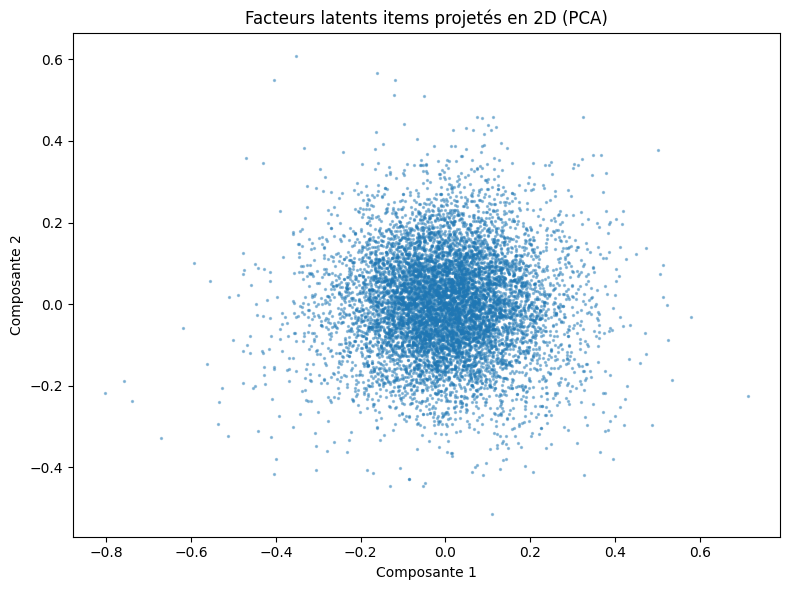

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

algo_full = ModelBaseline4()
algo_full.fit(trainset)

pca = PCA(n_components=2, random_state=1)
qi_2d = pca.fit_transform(algo_full.qi)
print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(8, 6))
plt.scatter(qi_2d[:, 0], qi_2d[:, 1], s=2, alpha=0.4)
plt.title("Item latent factors projected in 2D (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()

# 7. Folding-In Demonstration

For a **new user** not present in the trainset, their vector $p_u$ is estimated by solving:

$$A \, p_u = b \quad \text{with} \quad A = Q_{rated}^T Q_{rated} + \lambda I, \quad b = Q_{rated}^T \cdot \text{residuals}$$

where `residuals = ratings - mu - b_rated`.

In [ ]:
LAMBDA = 0.1
user_ratings_demo = {1: 4.0, 2: 3.5, 3: 5.0, 4: 3.0, 5: 4.5}

ts = algo_full.trainset
mu = ts.global_mean

rated = []
for raw_iid, r in user_ratings_demo.items():
    try:
        inner = ts.to_inner_iid(raw_iid)
        rated.append((inner, r))
    except ValueError:
        print(f"  film {raw_iid} unknown in trainset, skipped")

inner_ids = [x[0] for x in rated]
ratings   = np.array([x[1] for x in rated])
Q_rated   = algo_full.qi[inner_ids]
b_rated   = algo_full.bi[inner_ids]
residuals = ratings - mu - b_rated

n_factors = Q_rated.shape[1]
A  = Q_rated.T @ Q_rated + LAMBDA * np.eye(n_factors)
bv = Q_rated.T @ residuals
pu = np.linalg.solve(A, bv)
print(f"Vector pu — norm: {np.linalg.norm(pu):.4f}")

rated_inner = set(inner_ids)
all_scores  = mu + algo_full.bi + algo_full.qi @ pu
candidates  = [
    (int(ts.to_raw_iid(i)), float(np.clip(all_scores[i], 0.5, 5.0)))
    for i in range(ts.n_items) if i not in rated_inner
]
candidates.sort(key=lambda x: -x[1])

print("\nTop 10 recommendations (folding-in):")
for movie_id, score in candidates[:10]:
    title = df_items.loc[movie_id, C.LABEL_COL] if movie_id in df_items.index else "?"
    print(f"  movie_id={movie_id:6d}  score={score:.3f}  {title}")

Vecteur pu — norme : 1.8322

Top 10 recommandations (folding-in) :
  movie_id=  4993  score=5.000  Lord of the Rings: The Fellowship of the Ring, The (2001)
  movie_id=  5952  score=4.980  Lord of the Rings: The Two Towers, The (2002)
  movie_id= 58559  score=4.863  Dark Knight, The (2008)
  movie_id=  1254  score=4.768  Treasure of the Sierra Madre, The (1948)
  movie_id=  1148  score=4.731  Wallace & Gromit: The Wrong Trousers (1993)
  movie_id= 31658  score=4.684  Howl's Moving Castle (Hauru no ugoku shiro) (2004)
  movie_id=  2959  score=4.626  Fight Club (1999)
  movie_id=   232  score=4.615  Eat Drink Man Woman (Yin shi nan nu) (1994)
  movie_id=  1221  score=4.605  Godfather: Part II, The (1974)
  movie_id=  7502  score=4.604  Band of Brothers (2001)


# 8. Generating the Backend Artifact

In [ ]:
# Train final model with LatentFactorPP (SVD++) — Koren 2008 parameters
# Koren, Y. (2008). Factorization meets the neighborhood. KDD '08, pp. 426–434.
algo_pp = LatentFactorPP()
algo_pp.fit(trainset)

os.makedirs("backend/artifacts", exist_ok=True)
artifact_path = "backend/artifacts/svd_model.pkl"
with open(artifact_path, "wb") as f:
    pickle.dump(algo_pp, f)

print(f"Artifact saved: {artifact_path}")
print(f"  Model     : LatentFactorPP (SVD++)")
print(f"  n_factors : {algo_pp.n_factors}")
print(f"  n_epochs  : {algo_pp.n_epochs}")
print(f"  n_items   : {trainset.n_items}")
print(f"  n_users   : {trainset.n_users}")

# 9. Testing the Backend Model in Isolation

In [ ]:
from backend.models.svd import load, recommend

load()

test_ratings = {1: 4.0, 2: 3.5, 3: 5.0, 4: 3.0, 5: 4.5}
recs = recommend(test_ratings, n=10)

print(f"{len(recs)} recommendations received")
for movie_id, score in recs[:5]:
    title = df_items.loc[movie_id, C.LABEL_COL] if movie_id in df_items.index else "?"
    print(f"  movie_id={movie_id:6d}  score={score:.3f}  {title}")

assert len(recs) == 10
assert all(isinstance(mid, int) for mid, _ in recs)
assert all(0.5 <= s <= 5.0 for _, s in recs)
assert [s for _, s in recs] == sorted([s for _, s in recs], reverse=True)
print("\nAll checks passed.")

[svd] Modèle chargé — 9066 films.
10 recommandations reçues
  movie_id= 51080  score=4.702  Breach (2007)
  movie_id=  5662  score=4.614  Wrong Guy, The (1997)
  movie_id=116897  score=4.606  Wild Tales (2014)
  movie_id=  1859  score=4.591  Taste of Cherry (Ta'm e guilass) (1997)
  movie_id=  6669  score=4.546  Ikiru (1952)

Toutes les vérifications passées.
